In [1]:
import time
import sys
import os
import argparse
import io
from datetime import datetime
import numpy as np
import awkward as ak
import awkward
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from matplotlib import pyplot as plt
from torch.utils.tensorboard import SummaryWriter # to print to tensorboard
import torch.nn.functional as F
from torch_geometric.data import Data, Batch
from torch_geometric.nn import knn_graph, DynamicEdgeConv, global_mean_pool
from torch_geometric.nn import global_max_pool
#from torch_geometric.nn import DynamicEdgeConv

c:\Users\J Birbou\ML_Class\ml_env6\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")


Using device: cuda


In [3]:
DATA_PATH = "./data_pq/"
BATCH_SIZE = 64
EPOCHS = 30
LEARNING_RATE = 0.002
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

print(f"Using device: {DEVICE}")


Using device: cuda


In [4]:
DATA_PATH = "./data_pq/"  # path to the data

# Load the dataset
train_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "train.pq"))
val_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "val.pq"))
test_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "test.pq"))

In [5]:

# to get familiar with the dataset, let's inspect it.
print(f"The training dataset contains {len(train_dataset)} events.")
print(f"The validation dataset contains {len(val_dataset)} events.")
print(f"The test dataset contains {len(test_dataset)} events.")
print(f"The training dataset has the following columns: {train_dataset.fields}")
print(f"The validation dataset has the following columns: {val_dataset.fields}")
print(f"The test dataset has the following columns: {test_dataset.fields}")
# print the first event of the training dataset
print(f"The first event of the training dataset is: {train_dataset[0]}")

# We are interested in the labels xpos and ypos. This is the position of the neutrino interaction that we want to predict.
print(f"The first event of the training dataset has the following labels: {train_dataset['xpos'][0]}, {train_dataset['ypos'][0]}")
# Awkward arrays also allow us to obtain the 'xpos' and 'ypos' label for all events in the dataset
print(f"The first 10 labels of the training dataset are: {train_dataset['xpos'][:10]}, {train_dataset['ypos'][:10]}")

# The data can be accessed by using the 'data' key.
# The data is a 3D array with the first dimension being the number of events,
# the second dimension being the the three features (time, x, y)
# the third dimension being the number of hits,
print(f"The first event of the training dataset has {len(train_dataset['data'][0][0])} hits, i.e., detected photons.")
# Let's loop over all hits and print the time, x, and y coordinates of the first event.
for i in range(len(train_dataset['data'][0, 0])):
    print(f"Hit {i}: time = {train_dataset['data'][0,0,i]}, x = {train_dataset['data'][0,1, i]}, y = {train_dataset['data'][0,2,i]}")
# To get all hit times of the first event, you can use the following code:
print(f"The first event of the training dataset has the following hit times: {train_dataset['data'][0, 0]}")
print(f"The first event of the training dataset has the following hit x positions: {train_dataset['data'][0, 1]}")
print(f"The first event of the training dataset has the following hit y positions: {train_dataset['data'][0, 2]}")


The training dataset contains 10001 events.
The validation dataset contains 10001 events.
The test dataset contains 10001 events.
The training dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The validation dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The test dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The first event of the training dataset is: {xpos: 3.94, ypos: -7.12, data: [[14.5, ...], ...], energy: 10, xdir: 1, ...}
The first event of the training dataset has the following labels: 3.9371957858673263, -7.117557573556748
The first 10 labels of the training dataset are: [3.94, -9.2, 6.35, 6.41, -7.42, -7.27, 9.1, -1.87, -2.57, 0.981], [-7.12, -1.42, -4.1, 3.23, 4.68, -0.412, -0.377, -4.93, 1.34, 4.59]
The first event of the training dataset has 12 hits, i.e., detected photons.
Hit 0: time = 14.490445777588475, x = -2.5, y = -2.5
Hit 1: time = 17.1297022177257, x =

In [6]:
# Normalize data and labels
# working with Awkward arrays is a bit tricky because the ['data'] field can't be assigned in-place,
# so we need to extract the time, x, and y coordinates, normalize them separately,
# and then concatenate them back together.

def normalize_features(dataset, means=None, stds=None):
   
    times = dataset["data"][:, 0:1, :]
    x = dataset["data"][:, 1:2, :]
    y = dataset["data"][:, 2:3, :]
    
    if means is None or stds is None:
        means = {
            'time': awkward.mean(times), 'x': awkward.mean(x), 'y': awkward.mean(y),
            'xpos': awkward.mean(dataset['xpos']), 'ypos': awkward.mean(dataset['ypos'])
        }
        stds = {
            'time': awkward.std(times), 'x': awkward.std(x), 'y': awkward.std(y),
            'xpos': awkward.std(dataset['xpos']), 'ypos': awkward.std(dataset['ypos'])
        }

    norm_times = (times - means['time']) / stds['time']
    norm_x = (x - means['x']) / stds['x']
    norm_y = (y - means['y']) / stds['y']
    
    dataset["data"] = awkward.concatenate([norm_times, norm_x, norm_y], axis=1)
    dataset["xpos"] = (dataset["xpos"] - means['xpos']) / stds['xpos']
    dataset["ypos"] = (dataset["ypos"] - means['ypos']) / stds['ypos']
    
    return dataset, means, stds


train_dataset, norm_means, norm_stds = normalize_features(train_dataset)

val_dataset, _, _ = normalize_features(val_dataset, norm_means, norm_stds)
test_dataset, _, _ = normalize_features(test_dataset, norm_means, norm_stds)


# Hint: You can define a helper function to normalize the data and you can use the same normalization for the validation and test datasets.


In [7]:
# Create the DataLoader for training, validation, and test datasets
# Important: We use the custom collate function to preprocess the data for GNN (see the description of the collate function for details)
def collate_fn_gnn(batch):
    """
    Custom function that defines how batches are formed.

    For a more complicated dataset with variable length per event and Graph Neural Networks,
    we need to define a custom collate function which is passed to the DataLoader.
    The default collate function in PyTorch Geometric is not suitable for this case.

    This function takes the Awkward arrays, converts them to PyTorch tensors,
    and then creates a PyTorch Geometric Data object for each event in the batch.

    You do not need to change this function.

    Parameters
    ----------
    batch : list
        A list of dictionaries containing the data and labels for each graph.
        The data is available in the "data" key and the labels are in the "xpos" and "ypos" keys.
    Returns
    -------
    packed_data : Batch
        A batch of graph data objects.
    labels : torch.Tensor
        A tensor containing the labels for each graph.
    """
    data_list = []
    labels = []

    for b in batch:
        # this is a loop over each event within the batch
        # b["data"] is the first entry in the batch with dimensions (n_features, n_hits)
        # where the feautures are (time, x, y)
        # for training a GNN, we need the graph notes, i.e., the individual hits, as the first dimension,
        # so we need to transpose to get (n_hits, n_features)
        tensordata = torch.from_numpy(b["data"].to_numpy()).T
        # the original data is in double precision (float64), for our case single precision is sufficient
        # we let's convert to single precision (float32) to save memory and computation time
        tensordata = tensordata.to(dtype=torch.float32)

        # PyTorch Geometric needs the data in a specific format
        # we need to create a PyTorch Geometric Data object for each event
        this_graph_item = Data(x=tensordata)
        data_list.append(this_graph_item)

        # also the labels need to be packaged as pytorch tensors
        labels.append(torch.Tensor([b["xpos"], b["ypos"]]).unsqueeze(0))

    labels = torch.cat(labels, dim=0) # convert the list of tensors to a single tensor
    packed_data = Batch.from_data_list(data_list) # convert the list of Data objects to a single Batch object
    return packed_data, labels

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_gnn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_gnn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_gnn)


In [8]:
def MLP(in_channels, out_channels):
    """Helper function to build the Edge MLPs"""
    return nn.Sequential(
        nn.Linear(in_channels, out_channels // 2),
        nn.BatchNorm1d(out_channels // 2),
        nn.ReLU(),
        nn.Linear(out_channels // 2, out_channels),
        nn.BatchNorm1d(out_channels),
        nn.ReLU()
    )

In [9]:
#Defintion of the GNN model

# Use the DynamicEdgeConv layer from the pytorch geometric package like this:
# MLP is a Multi-Layer Perceptron that is used to compute the edge features, you still need to define it.
# The input dimension to the MLP should be twice the number of features in the input data (i.e., 2 * n_features),
# because the edge features are computed from the concatenation of the two nodes that are connected by the edge.
# The output dimension of the MLP is the new feauture dimension of this graph layer.

class GNNEncoder(nn.Module):
    def __init__(self, k=10):
        super(GNNEncoder, self).__init__()
        #self.k=k #check this and if/why it is needed
        self.layer1 = DynamicEdgeConv(
                    MLP(6,64), #check the results with more or less than 64
                    aggr='mean', k=k,  # # change 'mean' to 'max' and check the results
                )
        self.layer2 = DynamicEdgeConv(
                    MLP(128,128), 
                    aggr='mean', k=k,  # change 'mean' to 'max' and check the results
                )
        self.layer3 = DynamicEdgeConv(
                    MLP(256,256), 
                    aggr='mean', k=k,  # change 'mean' to 'max' and check the results
                )
        self.final_mlp = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(64, 2)
        )

    def forward(self, data):
        # data is a batch graph item. it contains a list of tensors (x) and how the batch is structured along this list (batch)
        x = data.x
        batch = data.batch
        """""
        # loop over the DynamicEdgeConv layers:
        for layer in self.layer_list:
            x = layer(x, batch)
        """
        
        x = self.layer1(x, batch)
        x = self.layer2(x, batch)
        x = self.layer3(x, batch)
        # the output of the last layer has dimensions (n_batch, n_nodes, graph_feature_dimension)
        # where n_batch is the number of graphs in the batch and n_nodes is the number of nodes in the graph
        # i.e. one output per node (i.e. the hits in the event).
        # To combine all node feauters into single prediction, we recommend to use global pooling
        x_pool_mean = global_mean_pool(x, batch) # -> (n_batch, output_dim)
        # x is now a tensor of shape (n_batch, output_dim)

        # either your the last graph feature dimension is already the output dimension you want to predict
        # or you need to add a final MLP layer to map the output dimension to the number of labels you want to predict
        
        #x_pool_max = global_max_pool(x, batch)
        #x_pooled = torch.cat([x_pool_mean, x_pool_max], dim=-1)
        x = self.final_mlp(x_pool_mean)

        return x

In [10]:
model = GNNEncoder().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

In [11]:
train_losses = []
val_losses = []
print("Starting training...")
for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0
    
    for batch_data, labels in train_loader:
        batch_data, labels = batch_data.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        predictions = model(batch_data)
        loss = criterion(predictions, labels)
        
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * labels.size(0)
        
    epoch_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    
    # Validation
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for batch_data, labels in val_loader:
            batch_data, labels = batch_data.to(DEVICE), labels.to(DEVICE)
            predictions = model(batch_data)
            loss = criterion(predictions, labels)
            running_val_loss += loss.item() * labels.size(0)
            
    epoch_val_loss = running_val_loss / len(val_dataset)
    val_losses.append(epoch_val_loss)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

Starting training...
Epoch 1/30 | Train Loss: 0.2389 | Val Loss: 0.1348
Epoch 2/30 | Train Loss: 0.1605 | Val Loss: 0.1072
Epoch 3/30 | Train Loss: 0.1476 | Val Loss: 0.1096
Epoch 4/30 | Train Loss: 0.1452 | Val Loss: 0.0987
Epoch 5/30 | Train Loss: 0.1422 | Val Loss: 0.1128
Epoch 6/30 | Train Loss: 0.1373 | Val Loss: 0.0973
Epoch 7/30 | Train Loss: 0.1352 | Val Loss: 0.0931
Epoch 8/30 | Train Loss: 0.1285 | Val Loss: 0.1084
Epoch 9/30 | Train Loss: 0.1335 | Val Loss: 0.0954
Epoch 10/30 | Train Loss: 0.1248 | Val Loss: 0.0975
Epoch 11/30 | Train Loss: 0.1271 | Val Loss: 0.0987
Epoch 12/30 | Train Loss: 0.1200 | Val Loss: 0.1083
Epoch 13/30 | Train Loss: 0.1226 | Val Loss: 0.1002
Epoch 14/30 | Train Loss: 0.1269 | Val Loss: 0.0985
Epoch 15/30 | Train Loss: 0.1175 | Val Loss: 0.0900
Epoch 16/30 | Train Loss: 0.1218 | Val Loss: 0.0911
Epoch 17/30 | Train Loss: 0.1158 | Val Loss: 0.0857
Epoch 18/30 | Train Loss: 0.1132 | Val Loss: 0.0960
Epoch 19/30 | Train Loss: 0.1179 | Val Loss: 0.1029


In [ ]:
import time
import sys
import os
import argparse
import io
from datetime import datetime
import numpy as np
import awkward as ak
import awkward
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
import torch.nn.functional as F
from torch_geometric.data import Data, Batch
from torch_geometric.nn import knn_graph, DynamicEdgeConv, global_mean_pool, global_max_pool

# --- Device Configuration ---
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

# --- Constants ---
DATA_PATH = "./data_pq/"
BATCH_SIZE = 64
EPOCHS = 30
LEARNING_RATE = 0.002
DEVICE = device

# --- Data Loading ---
train_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "train.pq"))
val_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "val.pq"))
test_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "test.pq"))

def normalize_features(dataset, means=None, stds=None):
    times = dataset["data"][:, 0:1, :]
    x = dataset["data"][:, 1:2, :]
    y = dataset["data"][:, 2:3, :]
    
    if means is None or stds is None:
        means = {
            'time': awkward.mean(times), 'x': awkward.mean(x), 'y': awkward.mean(y),
            'xpos': awkward.mean(dataset['xpos']), 'ypos': awkward.mean(dataset['ypos'])
        }
        stds = {
            'time': awkward.std(times), 'x': awkward.std(x), 'y': awkward.std(y),
            'xpos': awkward.std(dataset['xpos']), 'ypos': awkward.std(dataset['ypos'])
        }

    norm_times = (times - means['time']) / stds['time']
    norm_x = (x - means['x']) / stds['x']
    norm_y = (y - means['y']) / stds['y']
    
    dataset["data"] = awkward.concatenate([norm_times, norm_x, norm_y], axis=1)
    dataset["xpos"] = (dataset["xpos"] - means['xpos']) / stds['xpos']
    dataset["ypos"] = (dataset["ypos"] - means['ypos']) / stds['ypos']
    
    return dataset, means, stds

train_dataset, norm_means, norm_stds = normalize_features(train_dataset)
val_dataset, _, _ = normalize_features(val_dataset, norm_means, norm_stds)
test_dataset, _, _ = normalize_features(test_dataset, norm_means, norm_stds)

# --- DataLoader Collate Function ---
def collate_fn_gnn(batch):
    data_list = []
    labels = []

    for b in batch:
        tensordata = torch.from_numpy(b["data"].to_numpy()).T
        tensordata = tensordata.to(dtype=torch.float32)

        this_graph_item = Data(x=tensordata)
        data_list.append(this_graph_item)

        # Ensuring strictly float32 creation
        labels.append(torch.tensor([b["xpos"], b["ypos"]], dtype=torch.float32).unsqueeze(0))

    labels = torch.cat(labels, dim=0) 
    packed_data = Batch.from_data_list(data_list) 
    return packed_data, labels

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_gnn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_gnn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_gnn)

# --- Model Definition ---
def MLP(in_channels, out_channels):
    # Swapped to LeakyReLU for better gradient flow in graph spaces
    return nn.Sequential(
        nn.Linear(in_channels, out_channels),
        nn.BatchNorm1d(out_channels),
        nn.LeakyReLU(0.2),
        nn.Linear(out_channels, out_channels),
        nn.BatchNorm1d(out_channels),
        nn.LeakyReLU(0.2)
    )

class GNNEncoder(nn.Module):
    def __init__(self, k=16): 
        super(GNNEncoder, self).__init__()
        
        # DynamicEdgeConv takes 2 * in_channels as input to the MLP
        # Features: [time, x, y] -> in=3, MLP_in=6
        self.layer1 = DynamicEdgeConv(MLP(6, 64), aggr='max', k=k)
        self.layer2 = DynamicEdgeConv(MLP(128, 128), aggr='max', k=k)
        self.layer3 = DynamicEdgeConv(MLP(256, 256), aggr='max', k=k)
        
        # Project concatenated multi-scale features before pooling (64 + 128 + 256 = 448)
        self.feature_mixer = nn.Sequential(
            nn.Linear(448, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2)
        )
        
        # Final MLP takes mean+max pooled features: 512 * 2 = 1024
        self.final_mlp = nn.Sequential(
            nn.Linear(1024, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(p=0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(p=0.3),
            nn.Linear(128, 2)
        )

    def forward(self, data):
        x = data.x
        batch = data.batch
        
        x1 = self.layer1(x, batch)
        x2 = self.layer2(x1, batch)
        x3 = self.layer3(x2, batch)
        
        # Multi-scale feature concatenation
        x_cat = torch.cat([x1, x2, x3], dim=-1) 
        x_mixed = self.feature_mixer(x_cat)

        # Combined pooling
        x_pool_mean = global_mean_pool(x_mixed, batch) 
        x_pool_max = global_max_pool(x_mixed, batch)
        x_pooled = torch.cat([x_pool_mean, x_pool_max], dim=-1)
        
        out = self.final_mlp(x_pooled)
        return out

# --- Training Setup ---
model = GNNEncoder(k=16).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-3) 
criterion = nn.SmoothL1Loss()

# OneCycleLR is superior for a fixed number of epochs
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, 
    max_lr=LEARNING_RATE, 
    steps_per_epoch=len(train_loader), 
    epochs=EPOCHS
)

train_losses = []
val_losses = []
print("Starting training...")

# --- Training Loop ---
for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0
    
    for batch_data, labels in train_loader:
        batch_data, labels = batch_data.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        predictions = model(batch_data)
        loss = criterion(predictions, labels)
        
        loss.backward()
        optimizer.step()
        scheduler.step() # Note: OneCycleLR steps per batch, not per epoch
        
        running_train_loss += loss.item() * labels.size(0)
        
    epoch_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)
    
    # Validation
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for batch_data, labels in val_loader:
            batch_data, labels = batch_data.to(DEVICE), labels.to(DEVICE)
            predictions = model(batch_data)
            loss = criterion(predictions, labels)
            running_val_loss += loss.item() * labels.size(0)
            
    epoch_val_loss = running_val_loss / len(val_dataset)
    val_losses.append(epoch_val_loss)
    
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | LR: {current_lr:.6f}")

c:\Users\J Birbou\ML_Class\ml_env6\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Starting training...


c:\Users\J Birbou\ML_Class\ml_env6\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 1/30 | Train Loss: 0.0921 | Val Loss: 0.0501 | LR: 0.002000
Epoch 2/30 | Train Loss: 0.0665 | Val Loss: 0.0503 | LR: 0.002000
Epoch 3/30 | Train Loss: 0.0643 | Val Loss: 0.0438 | LR: 0.002000
Epoch 4/30 | Train Loss: 0.0614 | Val Loss: 0.0506 | LR: 0.002000
Epoch 5/30 | Train Loss: 0.0612 | Val Loss: 0.0477 | LR: 0.002000
Epoch 6/30 | Train Loss: 0.0601 | Val Loss: 0.0430 | LR: 0.002000
Epoch 7/30 | Train Loss: 0.0581 | Val Loss: 0.0611 | LR: 0.002000
Epoch 8/30 | Train Loss: 0.0585 | Val Loss: 0.0630 | LR: 0.002000
Epoch 9/30 | Train Loss: 0.0569 | Val Loss: 0.0448 | LR: 0.002000
Epoch 10/30 | Train Loss: 0.0562 | Val Loss: 0.0394 | LR: 0.002000
Epoch 11/30 | Train Loss: 0.0570 | Val Loss: 0.0507 | LR: 0.002000
Epoch 12/30 | Train Loss: 0.0561 | Val Loss: 0.0459 | LR: 0.002000
Epoch 13/30 | Train Loss: 0.0573 | Val Loss: 0.0507 | LR: 0.002000
Epoch 14/30 | Train Loss: 0.0569 | Val Loss: 0.0446 | LR: 0.001000
Epoch 15/30 | Train Loss: 0.0518 | Val Loss: 0.0458 | LR: 0.001000
Epoc

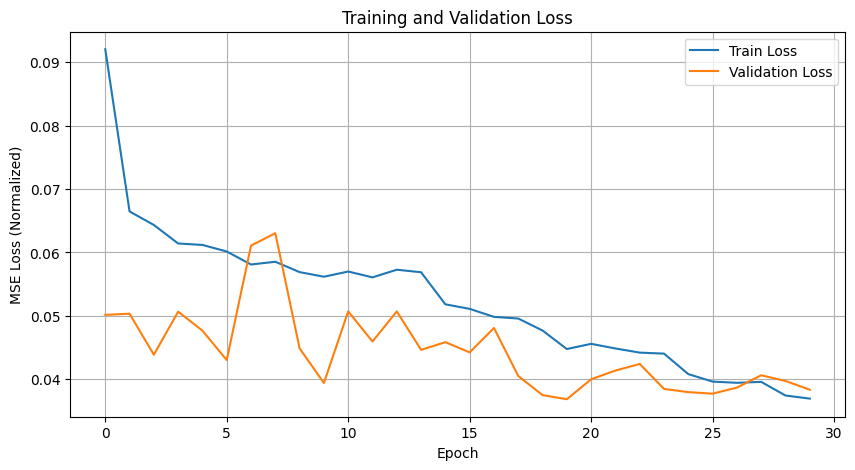

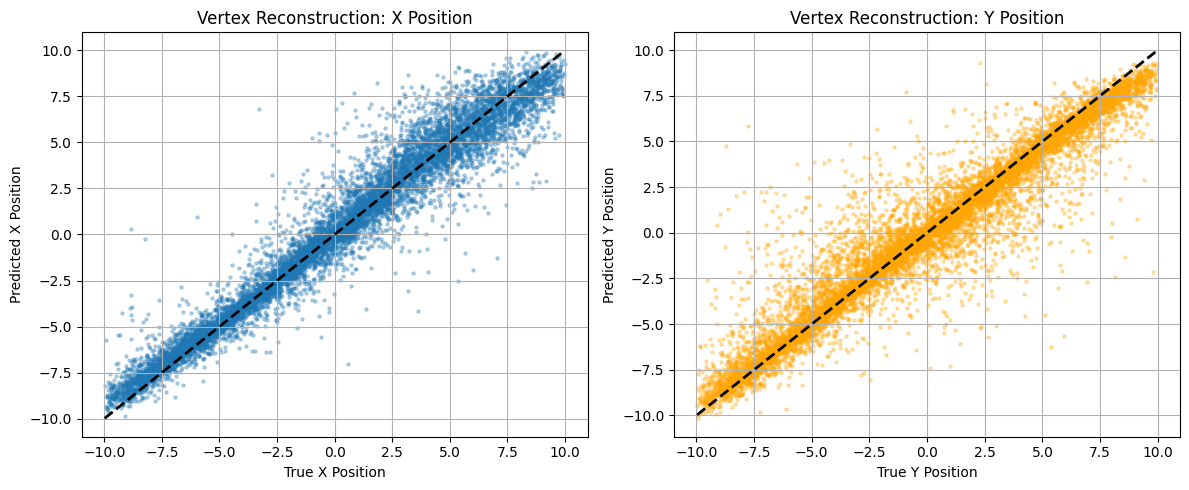

In [2]:

# Plot Loss Curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (Normalized)')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_curve.png')
plt.show()

# Evaluate on Test Set and Denormalize for Physics Analysis
model.eval()
all_preds = []
all_truths = []

with torch.no_grad():
    for batch_data, labels in test_loader:
        batch_data = batch_data.to(DEVICE)
        preds = model(batch_data).cpu().numpy()
        all_preds.append(preds)
        all_truths.append(labels.numpy())

all_preds = np.vstack(all_preds)
all_truths = np.vstack(all_truths)

# Denormalize
preds_x_real = (all_preds[:, 0] * norm_stds['xpos']) + norm_means['xpos']
preds_y_real = (all_preds[:, 1] * norm_stds['ypos']) + norm_means['ypos']
truths_x_real = (all_truths[:, 0] * norm_stds['xpos']) + norm_means['xpos']
truths_y_real = (all_truths[:, 1] * norm_stds['ypos']) + norm_means['ypos']

# Plot True vs Predicted Coordinates
plt.figure(figsize=(12, 5))

# X Position
plt.subplot(1, 2, 1)
plt.scatter(truths_x_real, preds_x_real, alpha=0.3, s=5)
plt.plot([min(truths_x_real), max(truths_x_real)], [min(truths_x_real), max(truths_x_real)], 'k--', lw=2)
plt.xlabel('True X Position')
plt.ylabel('Predicted X Position')
plt.title('Vertex Reconstruction: X Position')
plt.grid(True)

# Y Position
plt.subplot(1, 2, 2)
plt.scatter(truths_y_real, preds_y_real, alpha=0.3, s=5, color='orange')
plt.plot([min(truths_y_real), max(truths_y_real)], [min(truths_y_real), max(truths_y_real)], 'k--', lw=2)
plt.xlabel('True Y Position')
plt.ylabel('Predicted Y Position')
plt.title('Vertex Reconstruction: Y Position')
plt.grid(True)

plt.tight_layout()
plt.savefig('vertex_reconstruction.png')
plt.show()

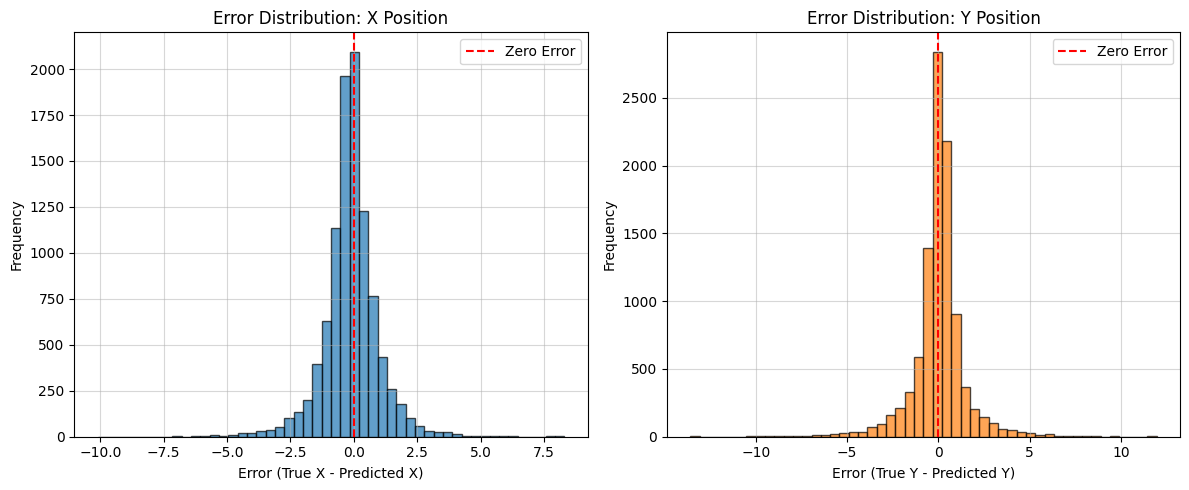

In [3]:
# Calculate residuals (True - Predicted)
residuals_x = truths_x_real - preds_x_real
residuals_y = truths_y_real - preds_y_real

# Plot Histogram of Residuals
plt.figure(figsize=(12, 5))

# X Residuals Histogram
plt.subplot(1, 2, 1)
plt.hist(residuals_x, bins=50, alpha=0.7, color='tab:blue', edgecolor='black')
plt.axvline(x=0, color='r', linestyle='--', linewidth=1.5, label='Zero Error')
plt.xlabel('Error (True X - Predicted X)')
plt.ylabel('Frequency')
plt.title('Error Distribution: X Position')
plt.legend()
plt.grid(True, alpha=0.5)

# Y Residuals Histogram
plt.subplot(1, 2, 2)
plt.hist(residuals_y, bins=50, alpha=0.7, color='tab:orange', edgecolor='black')
plt.axvline(x=0, color='r', linestyle='--', linewidth=1.5, label='Zero Error')
plt.xlabel('Error (True Y - Predicted Y)')
plt.ylabel('Frequency')
plt.title('Error Distribution: Y Position')
plt.legend()
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.savefig('residual_histograms.png')
plt.show()

In [4]:
import numpy as np

# Calculate Mean Absolute Error (MAE) for X and Y
mae_x = np.mean(np.abs(residuals_x))
mae_y = np.mean(np.abs(residuals_y))

# Calculate the mean of the absolute true values
mean_abs_true_x = np.mean(np.abs(truths_x_real))
mean_abs_true_y = np.mean(np.abs(truths_y_real))

# Calculate the relative average error
rel_error_x = mae_x / mean_abs_true_x
rel_error_y = mae_y / mean_abs_true_y

print(f"Mean Absolute Error (X): {mae_x:.4f}")
print(f"Mean Absolute Error (Y): {mae_y:.4f}")
print("---")
print(f"Relative Average Error (X): {rel_error_x:.6f} ({rel_error_x * 100:.2f}%)")
print(f"Relative Average Error (Y): {rel_error_y:.6f} ({rel_error_y * 100:.2f}%)")

Mean Absolute Error (X): 0.7619
Mean Absolute Error (Y): 0.9196
---
Relative Average Error (X): 0.179294 (17.93%)
Relative Average Error (Y): 0.218020 (21.80%)
